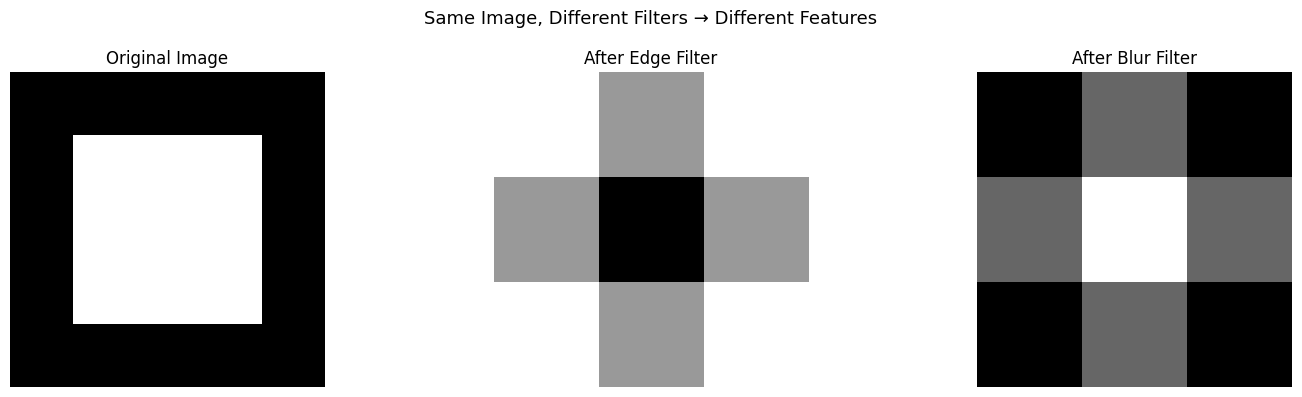

Key insight: In CNNs, the NETWORK learns what filters to use
We don't hand-craft them — backprop finds the optimal filters!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# A convolution = sliding a small filter over an image
# and computing dot products at each position

# Simple 5×5 "image"
image = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
], dtype=float)

# Kernels :
# 3×3 edge detection filter (Sobel-style)
filter_edge = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=float)

# 3×3 blur filter
filter_blur = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=float)

def convolve2d(image, kernel):

    h, w     = image.shape
    kh, kw   = kernel.shape
    out_h    = h - kh + 1                              # Output size of  the feature map, where the 3 things you set up is kernel size, stride, padding
    out_w    = w - kw + 1
    output   = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            # Extract patch and compute dot product with filter
            patch         = image[i:i+kh, j:j+kw]
            output[i, j]  = np.sum(patch * kernel)

    return output

result_edge = convolve2d(image, filter_edge)
result_blur = convolve2d(image, filter_blur)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(image,       cmap='gray'); axes[0].set_title("Original Image")
axes[1].imshow(result_edge, cmap='gray'); axes[1].set_title("After Edge Filter")
axes[2].imshow(result_blur, cmap='gray'); axes[2].set_title("After Blur Filter")

for ax in axes:
    ax.axis('off')

plt.suptitle("Same Image, Different Filters → Different Features", fontsize=13)
plt.tight_layout()
plt.show()

print("Key insight: In CNNs, the NETWORK learns what filters to use")
print("We don't hand-craft them — backprop finds the optimal filters!")


In [2]:
import torch
import torch.nn as nn

# Max Pooling: takes the MAX value in each patch
# Effect: reduces spatial size + retains strongest features
# Also provides translation invariance

# Create a sample feature map
feature_map = torch.tensor([[
    [1., 3., 2., 4.],
    [5., 6., 1., 2.],
    [3., 1., 4., 2.],
    [2., 8., 3., 1.]
]])

max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

result_max = max_pool(feature_map.unsqueeze(0))
result_avg = avg_pool(feature_map.unsqueeze(0))

print("Original feature map (4×4):")
print(feature_map.squeeze().numpy())

print("\nAfter MaxPool2d (2×2) → shape becomes (2×2):")
print(result_max.squeeze().numpy())
# Top-left 2×2: [1,3,5,6] → max = 6
# Top-right 2×2: [2,4,1,2] → max = 4

print("\nAfter AvgPool2d (2×2):")
print(result_avg.squeeze().numpy())

print("\nWhy MaxPool is used more:")
print("It keeps the STRONGEST activations (detected features)")
print("AvgPool blurs feature responses")


Original feature map (4×4):
[[1. 3. 2. 4.]
 [5. 6. 1. 2.]
 [3. 1. 4. 2.]
 [2. 8. 3. 1.]]

After MaxPool2d (2×2) → shape becomes (2×2):
[[6. 4.]
 [8. 4.]]

After AvgPool2d (2×2):
[[3.75 2.25]
 [3.5  2.5 ]]

Why MaxPool is used more:
It keeps the STRONGEST activations (detected features)
AvgPool blurs feature responses


In [5]:
import torch
import torch.nn as nn

class CNNFromScratch(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)       
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)
    
    def forward (self, x):
        x = self.pool(self.relu(self.conv1(x)))       # 32 - 3 + 1 = 28, then after pool 28 gets halved to 14 i.e., (batch,32,28,28) → (batch,32,14,14)
        x = self.pool(self.relu(self.conv2(x)))       # |||ly  (batch,32,14,14) → (batch,64,14,14) → (batch,64,7,7) 
        x = x.view(x.size(0), -1)                     # (batch, 64*7*7) = (batch, 3136)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = CNNFromScratch()
print(model)
print("Total Parameters : ", sum(p.numel() for p in model.parameters()))

dummy = torch.randn(1, 1, 28, 28)
print(f"\nInput shape:  {dummy.shape}")

with torch.no_grad():
    out = model(dummy)
print(f"Output shape: {out.shape}")    # should be (1, 10)

CNNFromScratch(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Total Parameters :  421642

Input shape:  torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 10])


Epoch 1 | Loss: 0.1622 | Acc: 95.0%
Epoch 2 | Loss: 0.0519 | Acc: 98.4%
Epoch 3 | Loss: 0.0380 | Acc: 98.8%
Epoch 4 | Loss: 0.0293 | Acc: 99.1%
Epoch 5 | Loss: 0.0246 | Acc: 99.2%


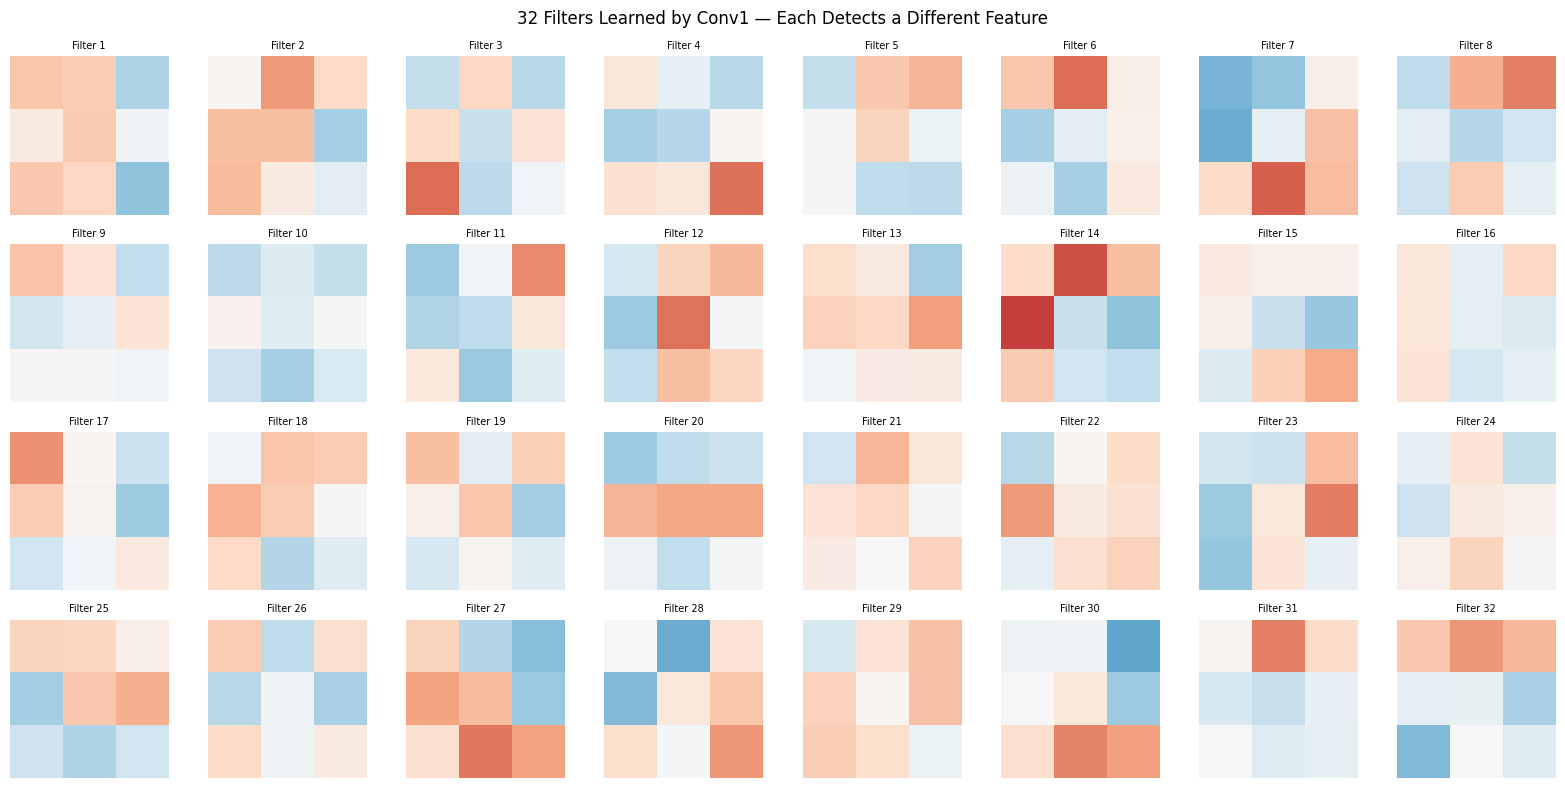

In [6]:
from torchvision import datasets, transforms

# Loading MNSIT 
transform    = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_data   = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_data    = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=64, shuffle=False)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = CNNFromScratch().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    model.train()
    correct, total, running_loss = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (pred == labels).sum().item()
    print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f} | Acc: {100*correct/total:.1f}%")

# Visualizing the 32 filters learned by conv1
filters = model.conv1.weight.data.cpu()   # shape: (32, 1, 3, 3)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i < 32:
        filt = filters[i, 0].numpy()
        ax.imshow(filt, cmap='RdBu', vmin=-1, vmax=1)
        ax.set_title(f"Filter {i+1}", fontsize=7)
    ax.axis('off')

plt.suptitle("32 Filters Learned by Conv1 — Each Detects a Different Feature", fontsize=12)
plt.tight_layout()
plt.show()



- Deep RED   →  large positive weight  (+1)  "strongly activate when pixel is bright here"
- WHITE      →  weight near zero       (0)   "don't care about this position"
- Deep BLUE  →  large negative weight  (-1)  "strongly activate when pixel is DARK here"

- Filter 1  →  vertical edge detector  (bright left, dark right)
- Filter 7  →  diagonal transition     (bright top-left to dark bottom-right)
- Filter 14 →  top-bright stroke end   (bright top-center, dark right)
- Filter 16 →  nearly blank            (redundant — not needed)...and so on for all 32

- Raw pixels   →   meaningless numbers
- After Conv1  →   "is there a vertical stroke here? a diagonal? a curve?"
- After Conv2  →   "are there TWO strokes forming an angle? a loop?"
- After Linear →   "that combination = digit 3, with 97% confidence"


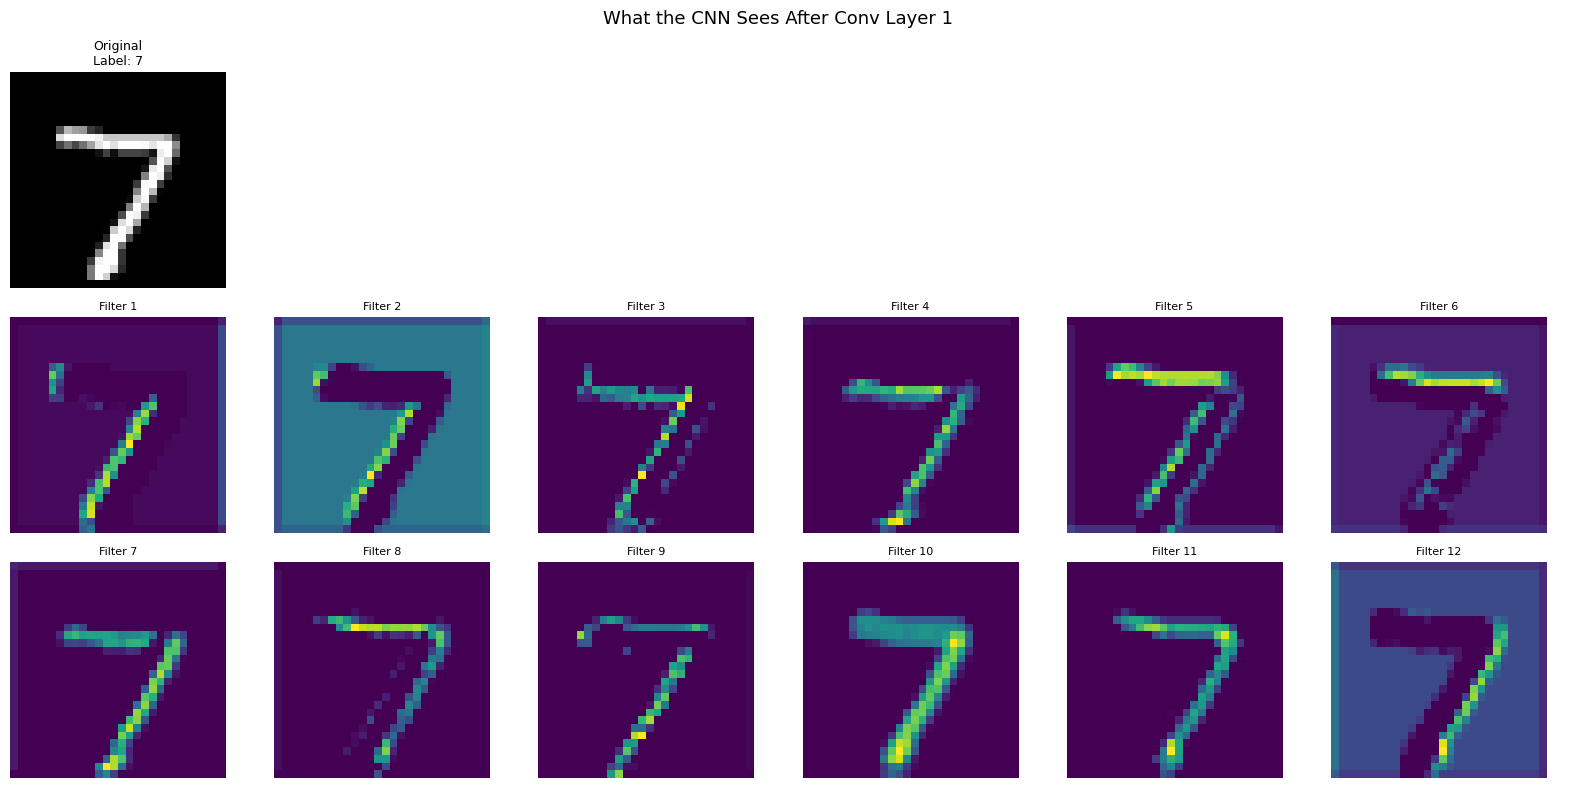

In [7]:
# Visualize feature maps: what does the network "see"?
model.eval()
sample_image = test_data[0][0].unsqueeze(0).to(device)   # shape: (1,1,28,28)

with torch.no_grad():
    # Get activations after conv1
    after_conv1 = model.relu(model.conv1(sample_image))   # (1, 32, 28, 28)

# Plot original + first 16 feature maps
fig, axes = plt.subplots(3, 6, figsize=(16, 8))

# Original image
axes[0, 0].imshow(test_data[0][0].squeeze(), cmap='gray')
axes[0, 0].set_title(f"Original\nLabel: {test_data[0][1]}", fontsize=9)
axes[0, 0].axis('off')

# Hide remaining cells in first row
for j in range(1, 6):
    axes[0, j].axis('off')

# Feature maps
feature_maps = after_conv1.squeeze().cpu().numpy()   # (32, 28, 28)
for i in range(12):
    row = (i // 6) + 1
    col = i % 6
    axes[row, col].imshow(feature_maps[i], cmap='viridis')
    axes[row, col].set_title(f"Filter {i+1}", fontsize=8)
    axes[row, col].axis('off')

plt.suptitle("What the CNN Sees After Conv Layer 1", fontsize=13)
plt.tight_layout()
plt.show()


## Feature Map Analysis — What Each Filter Detected in the "7"

The digit "7" has two key structural components:
- **Top horizontal stroke** ━━━━━━ (the top bar, running left → right)
- **Diagonal slash stroke** ╱ (the body running top-right → bottom-left)

Each feature map below is that filter's **answer map** — bright yellow = strong match, dark purple = no match.

---

### Filter 1 — Diagonal Edge Detector
- Yellow spots **only on the diagonal slash ╱**, top stroke nearly invisible
- Narrow, specialized detector tuned to one specific edge direction
- Matched the **top-right → bottom-left angle** of the diagonal but ignored the horizontal top

---

### Filter 2 — Brightness / Presence Detector
- Entire image glows **teal**, including the background
- Not edge-specific — detects **"is there any ink here?"**
- Large uniform positive weights → captures the full shape outline but not discriminative

---

### Filter 3 — Corner / Junction Detector
- One intense **yellow hotspot exactly where the top stroke meets the diagonal ╱**
- The junction sits at the **top-left end of the horizontal bar** where it transitions into the downward slash
- Classic **corner detector** — fires hardest at the most structurally unique point of a "7"

---

### Filter 4 — General Stroke Presence Detector
- Both strokes lit up **evenly**, no single hotspot
- Doesn't care about direction — detects **"is there a stroke of this thickness here?"**
- Uniform response along all ink regions

---

### Filter 5 — Horizontal Stroke Detector
- Top horizontal stroke is **blazing yellow**
- Diagonal ╱ is dimmer (green/teal) because it's off-axis
- Specializes in **horizontal edges** — the top bar of the "7" is its perfect match

---

### Filter 6 — Horizontal Detector (variant)
- Nearly identical to Filter 5 but with slightly different orientation tuning
- Backprop discovered **two similar horizontal detectors** are more useful than one
- Catches slightly different angles of horizontal strokes across different handwriting styles

---

### Filter 7 — Low-Frequency / Blur Detector
- Broad **soft glow** across the whole digit, no sharp hotspots
- Equivalent to a blur/smoothing kernel — captures **overall shape presence**
- No sharp edge discrimination, just diffuse ink detection

---

### Filter 8 — Stroke Endpoint Detector (Top-Right)
- Bright yellow **only at the right tip of the horizontal top stroke**
- Detects stroke termination: bright pixel adjacent to sudden darkness
- Captures the **right endpoint** of the "7"'s top bar

---

### Filter 9 — Near-Blank (Curve/Loop Detector)
- Very sparse activation — **almost nothing lit up**
- This filter's learned pattern doesn't exist in a "7"
- Likely specialized for **curves or loops** (digits 0, 6, 8, 9) — "no match found"

---

### Filter 10 — Stroke Endpoint Detector (Bottom-Left)
- Strong activation at the **very bottom-left tip of the diagonal slash ╱**
- Complements Filter 8 — together they bracket both endpoints of the "7"
- Bottom stroke termination: the ╱ diagonal lands at the **bottom-left**, bright pixel → sudden darkness

---

### Filter 11 — General Stroke Detector (variant)
- Clean full outline of both strokes, similar to Filter 4
- Slightly different weight balance → responds to different **pixel intensity ranges**
- Redundant but robust — covers what Filter 4 misses at certain contrast levels

---

### Filter 12 — Inverted / Suppression Detector
- Background has a **blue tint**, digit appears teal/lighter
- Negative weights on background pixels, positive on stroke pixels
- Actively **suppresses dark areas** and highlights bright strokes — inverted response pattern

---

## 🔗 Filter Weights → Feature Map Connection

| Filter Weight Pattern | Feature Map Result |
|---|---|
| Strong horizontal weights in top row | Top stroke blazing yellow (Filters 5, 6) |
| Strong diagonal weights top-right → bottom-left | Diagonal slash ╱ bright (Filter 1) |
| Uniform positive weights everywhere | Whole digit glows, no direction (Filter 2) |
| Large center weight, small surroundings | Stroke endpoints only (Filters 8, 10) |
| Near-zero weights everywhere | Nearly blank map — no match (Filter 9) |
| Negative background weights | Blue background, inverted feel (Filter 12) |

> **Key insight:** Each feature map is the filter's 3×3 question stamped across every pixel position of the "7".  
> The diagonal ╱ runs **top-right → bottom-left** — filters tuned to this direction fire along the slash body,  
> while filters tuned to horizontal fire along the top bar. Together, 32 partial descriptions combine  
> in the next layer into: *"this collection of stroke patterns = digit 7 with 99% confidence."*


In [8]:
# Evaluate CNN on test set

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs        = model(images)
        _, predicted   = torch.max(outputs, 1)
        total         += labels.size(0)
        correct       += (predicted == labels).sum().item()

cnn_accuracy = 100 * correct / total
print(f"CNN Test Accuracy: {cnn_accuracy:.2f}%")

# Compare to Day 7 fully connected net
print(f"\nDay 7  - Fully Connected Net: ~97-98%")
print(f"Day 12 - CNN:                  {cnn_accuracy:.2f}%")
print(f"\nCNN wins with FAR fewer parameters in the conv layers")
print(f"CNN parameters: {sum(p.numel() for p in model.parameters()):,}")


CNN Test Accuracy: 99.11%

Day 7  - Fully Connected Net: ~97-98%
Day 12 - CNN:                  99.11%

CNN wins with FAR fewer parameters in the conv layers
CNN parameters: 421,642


In [9]:
# WHY CNNs are so efficient — parameter counting
print("PARAMETER COMPARISON")
print("=" * 50)

# Fully connected approach for 28×28 images
fc_params = 784 * 256 + 256 * 128 + 128 * 10
print(f"Fully Connected (Day 7): {fc_params:,} parameters")

# CNN approach
conv1_params = 32 * 1 * 3 * 3 + 32   # filters + biases
conv2_params = 64 * 32 * 3 * 3 + 64
fc_params_cnn = 64*7*7 * 128 + 128 + 128*10 + 10
total_cnn = conv1_params + conv2_params + fc_params_cnn
print(f"CNN (Day 12):            {total_cnn:,} parameters")

print(f"\nKey: conv layers use only {conv1_params + conv2_params:,} params")
print(f"to process the ENTIRE image — same filter slides everywhere!")
print(f"This is called WEIGHT SHARING — the CNN's superpower")


PARAMETER COMPARISON
Fully Connected (Day 7): 234,752 parameters
CNN (Day 12):            421,642 parameters

Key: conv layers use only 18,816 params
to process the ENTIRE image — same filter slides everywhere!
This is called WEIGHT SHARING — the CNN's superpower
